In [1]:
%cd /home

/home


In [2]:
import numpy as np
import matplotlib.pyplot  as plt
import os

In [3]:
data_example = np.load(r"/mnt/sciml/data_assimilation/da_arctic_2015-2024_v0.1/preds/ocean+atmosphere_24_2015-01-17.npy")

In [4]:
data_example.shape

(15, 24, 311, 225)

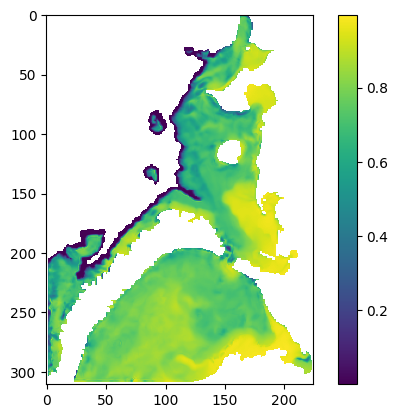

In [5]:
plt.imshow(data_example[0][0])
plt.colorbar()
plt.show()

In [6]:
target_shape = (320, 240)
pad_height = target_shape[0] - data_example[0][0].shape[0]
pad_width = target_shape[1] - data_example[0][0].shape[1]


In [7]:
data_example.shape

(15, 24, 311, 225)

In [8]:
import numpy as np
import os
from pathlib import Path

def process_tensors(input_folder, output_folder):

    Path(output_folder).mkdir(parents=True, exist_ok=True)
    target_shape = (2, 320, 256)

    for i, filename in enumerate(sorted(os.listdir(input_folder))):
        
        if '2022' in filename or '2023' in filename or '2024' in filename:
            print(f"Пропускаем файл (содержит 2022/2023): {filename}")
            continue
        
        if filename.endswith('.npy'):
            input_path = os.path.join(input_folder, filename)
            
            tensor = np.load(input_path)
            print(f"Обработка {filename}, исходная форма: {tensor.shape}")
            
            n = tensor.shape[1]
            for i in range(n):
                slice_tensor = tensor[:, i, :, :]
                
                slice_tensor = slice_tensor[:2, :, :]  
                slice_tensor = np.nan_to_num(slice_tensor, nan=0.0)
                height_diff = target_shape[1] - slice_tensor.shape[1] 
                width_diff = target_shape[2] - slice_tensor.shape[2]
                
                height_start = height_diff // 2 
                width_start = width_diff // 2 
                
                processed_tensor = np.pad(
                slice_tensor, 
                pad_width=((0, 0), (height_start, height_diff - height_start),(width_start, width_diff - width_start)), 
                mode='constant',
                constant_values=0
                )
                
                base_name = os.path.splitext(filename)[0]
                output_filename = f"{base_name}_processed{i:03d}.npy"
                output_path = os.path.join(output_folder, output_filename)
                np.save(output_path, processed_tensor)
                    
            print(f"  Создано {n} файлов из {filename}")

In [9]:
input_folder = "/mnt/sciml/data_assimilation/da_arctic_2015-2024_v0.1/preds"
output_folder = "/mnt/sciml/a.sadreev/sea_ice_data/train"

process_tensors(input_folder, output_folder)

Обработка ocean+atmosphere_24_2015-01-17.npy, исходная форма: (15, 24, 311, 225)
  Создано 24 файлов из ocean+atmosphere_24_2015-01-17.npy
Обработка ocean+atmosphere_24_2015-01-18.npy, исходная форма: (15, 24, 311, 225)
  Создано 24 файлов из ocean+atmosphere_24_2015-01-18.npy
Обработка ocean+atmosphere_24_2015-01-19.npy, исходная форма: (15, 24, 311, 225)
  Создано 24 файлов из ocean+atmosphere_24_2015-01-19.npy
Обработка ocean+atmosphere_24_2015-01-20.npy, исходная форма: (15, 24, 311, 225)
  Создано 24 файлов из ocean+atmosphere_24_2015-01-20.npy
Обработка ocean+atmosphere_24_2015-01-21.npy, исходная форма: (15, 24, 311, 225)
  Создано 24 файлов из ocean+atmosphere_24_2015-01-21.npy
Обработка ocean+atmosphere_24_2015-01-22.npy, исходная форма: (15, 24, 311, 225)
  Создано 24 файлов из ocean+atmosphere_24_2015-01-22.npy
Обработка ocean+atmosphere_24_2015-01-23.npy, исходная форма: (15, 24, 311, 225)
  Создано 24 файлов из ocean+atmosphere_24_2015-01-23.npy
Обработка ocean+atmosphere_

In [72]:
data_processed_example = np.load('/mnt/sciml/a.sadreev/sea_ice_data/train/ocean+atmosphere_24_2021-02-17_processed000.npy')

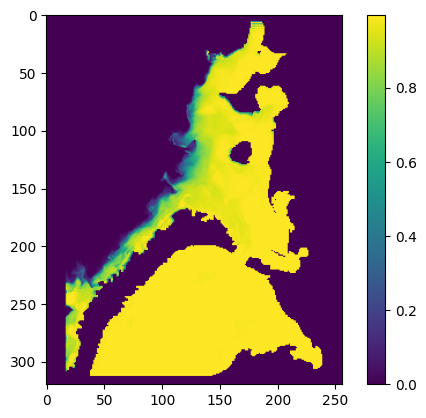

In [ ]:
plt.imshow(data_processed_example[0])
plt.colorbar()
plt.show()

In [60]:
data_processed_example.shape

(2, 320, 256)

In [74]:
import numpy as np
import os
from pathlib import Path

def process_tensors_valid(input_folder, output_folder):

    Path(output_folder).mkdir(parents=True, exist_ok=True)
    target_shape = (2, 320, 256)

    for i, filename in enumerate(sorted(os.listdir(input_folder))):
        
        if '2022' in filename:
            
            if filename.endswith('.npy'):
                input_path = os.path.join(input_folder, filename)
                
                tensor = np.load(input_path)
                print(f"Обработка {filename}, исходная форма: {tensor.shape}")
                
                n = tensor.shape[1]
                for i in range(n):
                    slice_tensor = tensor[:, i, :, :]
                    
                    slice_tensor = slice_tensor[:2, :, :]  
                    slice_tensor = np.nan_to_num(slice_tensor, nan=0.0)
                    height_diff = target_shape[1] - slice_tensor.shape[1] 
                    width_diff = target_shape[2] - slice_tensor.shape[2]
                    
                    height_start = height_diff // 2 
                    width_start = width_diff // 2 
                    
                    processed_tensor = np.pad(
                    slice_tensor, 
                    pad_width=((0, 0), (height_start, height_diff - height_start),(width_start, width_diff - width_start)), 
                    mode='constant',
                    constant_values=0
                    )
                    
                    base_name = os.path.splitext(filename)[0]
                    output_filename = f"{base_name}_processed{i:03d}.npy"
                    output_path = os.path.join(output_folder, output_filename)
                    np.save(output_path, processed_tensor)
                    
            print(f"  Создано {n} файлов из {filename}")

In [75]:
input_folder = "/mnt/sciml/data_assimilation/da_arctic_2015-2024_v0.1/preds"
output_folder = "/mnt/sciml/a.sadreev/sea_ice_data/valid"

process_tensors_valid(input_folder, output_folder)

Обработка ocean+atmosphere_24_2022-01-01.npy, исходная форма: (15, 24, 311, 225)
  Создано 15 файлов из ocean+atmosphere_24_2022-01-01.npy
Обработка ocean+atmosphere_24_2022-01-02.npy, исходная форма: (15, 24, 311, 225)
  Создано 15 файлов из ocean+atmosphere_24_2022-01-02.npy
Обработка ocean+atmosphere_24_2022-01-03.npy, исходная форма: (15, 24, 311, 225)
  Создано 15 файлов из ocean+atmosphere_24_2022-01-03.npy
Обработка ocean+atmosphere_24_2022-01-04.npy, исходная форма: (15, 24, 311, 225)
  Создано 15 файлов из ocean+atmosphere_24_2022-01-04.npy
Обработка ocean+atmosphere_24_2022-01-05.npy, исходная форма: (15, 24, 311, 225)
  Создано 15 файлов из ocean+atmosphere_24_2022-01-05.npy
Обработка ocean+atmosphere_24_2022-01-06.npy, исходная форма: (15, 24, 311, 225)
  Создано 15 файлов из ocean+atmosphere_24_2022-01-06.npy
Обработка ocean+atmosphere_24_2022-01-07.npy, исходная форма: (15, 24, 311, 225)
  Создано 15 файлов из ocean+atmosphere_24_2022-01-07.npy
Обработка ocean+atmosphere_

In [76]:
import numpy as np
import os
from pathlib import Path

def process_tensors_test(input_folder, output_folder):

    Path(output_folder).mkdir(parents=True, exist_ok=True)
    target_shape = (2, 320, 256)

    for i, filename in enumerate(sorted(os.listdir(input_folder))):
        
        if '2023' in filename:
            
            if filename.endswith('.npy'):
                input_path = os.path.join(input_folder, filename)
                
                tensor = np.load(input_path)
                print(f"Обработка {filename}, исходная форма: {tensor.shape}")
                
                n = tensor.shape[1]
                for i in range(n):
                    slice_tensor = tensor[:, i, :, :]
                    
                    slice_tensor = slice_tensor[:2, :, :]  
                    slice_tensor = np.nan_to_num(slice_tensor, nan=0.0)
                    height_diff = target_shape[1] - slice_tensor.shape[1] 
                    width_diff = target_shape[2] - slice_tensor.shape[2]
                    
                    height_start = height_diff // 2 
                    width_start = width_diff // 2 
                    
                    processed_tensor = np.pad(
                    slice_tensor, 
                    pad_width=((0, 0), (height_start, height_diff - height_start),(width_start, width_diff - width_start)), 
                    mode='constant',
                    constant_values=0
                    )
                    
                    base_name = os.path.splitext(filename)[0]
                    output_filename = f"{base_name}_processed{i:03d}.npy"
                    output_path = os.path.join(output_folder, output_filename)
                    np.save(output_path, processed_tensor)
                    
            print(f"  Создано {n} файлов из {filename}")

In [77]:
input_folder = "/mnt/sciml/data_assimilation/da_arctic_2015-2024_v0.1/preds"
output_folder = "/mnt/sciml/a.sadreev/sea_ice_data/test"

process_tensors_test(input_folder, output_folder)

Обработка ocean+atmosphere_24_2023-01-01.npy, исходная форма: (15, 24, 311, 225)
  Создано 15 файлов из ocean+atmosphere_24_2023-01-01.npy
Обработка ocean+atmosphere_24_2023-01-02.npy, исходная форма: (15, 24, 311, 225)
  Создано 15 файлов из ocean+atmosphere_24_2023-01-02.npy
Обработка ocean+atmosphere_24_2023-01-03.npy, исходная форма: (15, 24, 311, 225)
  Создано 15 файлов из ocean+atmosphere_24_2023-01-03.npy
Обработка ocean+atmosphere_24_2023-01-04.npy, исходная форма: (15, 24, 311, 225)
  Создано 15 файлов из ocean+atmosphere_24_2023-01-04.npy
Обработка ocean+atmosphere_24_2023-01-05.npy, исходная форма: (15, 24, 311, 225)
  Создано 15 файлов из ocean+atmosphere_24_2023-01-05.npy
Обработка ocean+atmosphere_24_2023-01-06.npy, исходная форма: (15, 24, 311, 225)
  Создано 15 файлов из ocean+atmosphere_24_2023-01-06.npy
Обработка ocean+atmosphere_24_2023-01-07.npy, исходная форма: (15, 24, 311, 225)
  Создано 15 файлов из ocean+atmosphere_24_2023-01-07.npy
Обработка ocean+atmosphere_